In [18]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import math
from tweezepy import allanvar as tpy
import allanself
import statistics
import scipy

In [2]:
df = allanself.process_data('ICRF3 Dem/series_ind_dem/1803+784_dem.txt')
df.head(5)

,MJD,R.A. (mas),Dec. (mas),Err. R.A. (mas),Err. Dec. (mas),Corr.,Del.,R.A. (micas),Dec. (micas),Err. R.A. (micas),Err. Dec. (micas),Dec. (rad),RAcosDEC,BY
0,45754.258,-1.910705,-1.887599,1.2912,0.7417,-0.084,40,-1910.704737,-1887.598813,1291.2,741.7,-9.151337e-09,-1910.704737,1984.147297
1,45759.251,-1.555439,-2.306200,1.2032,1.1362,0.028,19,-1555.438834,-2306.199571,1203.2,1136.2,-1.118077e-08,-1555.438834,1984.160968
2,45764.244,0.049960,1.459800,0.7069,0.6182,0.325,21,49.959984,1459.800012,706.9,618.2,7.077310e-09,49.959984,1984.174638
3,45769.259,-5.739611,0.890402,2.5316,1.1073,-0.363,25,-5739.611378,890.402401,2531.6,1107.3,4.316793e-09,-5739.611378,1984.188369
4,45864.264,-2.973084,0.696002,0.6484,0.6307,0.547,27,-2973.083789,696.002411,648.4,630.7,3.374315e-09,-2973.083789,1984.448484


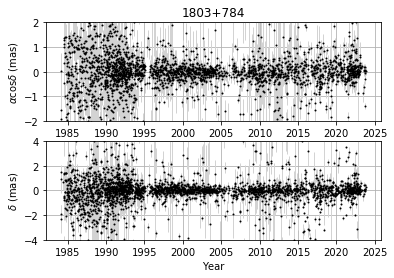

In [3]:
plt.subplot(211)
plt.title('1803+784')
plt.errorbar(df['BY'], df['RAcosDEC']/1000,yerr=df['Err. R.A. (mas)'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1)
plt.ylim(-2,2)
plt.xlabel('Year')
plt.ylabel(r'$\alpha \cos \delta$ (mas)')
plt.grid()
plt.subplot(212)
plt.errorbar(df['BY'], df['Dec. (mas)'], yerr=df['Err. Dec. (mas)'], fmt='o', ms=1, mec='black', ecolor='lightgrey', elinewidth=1)
plt.ylim(-4,4)
plt.xlabel('Year')
plt.ylabel('$\delta$ (mas)')
plt.grid()
plt.show()

In [4]:
# Choose data under 2015
df_sel = df[df['BY'] < 2015]
len(df_sel)

2234

In [5]:
df_sel_dec = allanself.remove_outliers(df_sel,'DEC')
len(df_sel_dec)

2213

In [6]:
df_sel_ra = allanself.remove_outliers(df_sel,'RA')
len(df_sel_ra)

2216

In [7]:
%%time
tau_dec, allanstd_dec, edfs_dec = allanself.allanoadev(df_sel_dec['Dec. (micas)'].values,df_sel_dec['MJD'].values,df_sel_dec['Err. Dec. (micas)'].values)

CPU times: user 5min, sys: 36.1 ms, total: 5min
Wall time: 5min


In [19]:
def process_allan(y,tau,edfs):
    tau_year = [x/365.242198781 for x in tau]
    samplevar = statistics.variance(y)
    bottom = edfs*samplevar/scipy.stats.chi2.ppf(1-0.1/2,edfs)
    top = scipy.stats.chi2.ppf(0.1/2,edfs)
    top_alt = edfs*samplevar/scipy.stats.chi2.ppf(0.1/2,edfs)
    return tau_year,bottom,top,top_alt

In [20]:
tau_dec_year, bottom_dec, top_dec, top_alt_dec = process_allan(c,tau_dec,edfs_dec)

In [31]:
statistics.pvariance(df_sel_dec['Dec. (micas)'].values)

9512492.91872031

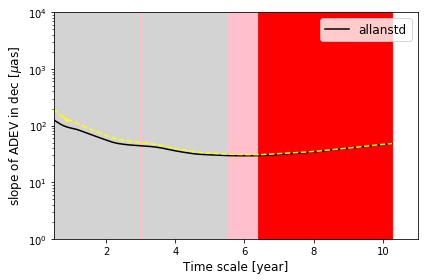

In [22]:
plt.figure()
# Calculate the slopes
slopes_dec = np.diff(np.log10(allanstd_dec)) / np.diff(np.log10(tau_dec))
# Plot allanstd
plt.plot(tau_dec_year,allanstd_dec,color='black',label='allanstd')
# Color background according to the slopes / noise type
plt.fill_between(tau_dec_year[1:], 1, 10**4, where= slopes_dec  < -0.25,color='lightgray',linewidth=1.0,zorder=1)
plt.fill_between(tau_dec_year[1:], 1, 10**4, where= (-0.25 <= slopes_dec ) & (slopes_dec  <= 0.25),color='pink',linewidth=1.0)
plt.fill_between(tau_dec_year[1:], 1, 10**4, where= slopes_dec  > 0.25,color='red',step='mid',linewidth=1.0)
# Plot confidence interval
plt.plot(tau_dec_year, allanstd_dec - bottom_dec,color='green',linestyle='dashed')
plt.plot(tau_dec_year, allanstd_dec + top_dec,color='yellow',linestyle='dashed')
plt.plot(tau_dec_year, allanstd_dec + top_alt_dec,color='blue',linestyle='dashed')

plt.yscale('log')
plt.xlabel('Time scale [year]', fontsize=12)
plt.ylabel(r'slope of ADEV in dec [$\mu$as]', fontsize=12)
plt.legend(fontsize=12)
plt.ylim(1,10**4)
plt.xlim(0.5,11)
plt.tight_layout()

In [33]:
statistics.variance(df_sel_dec['Dec. (micas)'].values)

9516793.322390618